In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

In [2]:
application = pd.read_csv("application_data.csv")
previous = pd.read_csv("previous_application.csv")

In [3]:
print("Application Shape:", application.shape)
print("Previous Shape:", previous.shape)

Application Shape: (21340, 122)
Previous Shape: (42611, 37)


In [4]:
application.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21340 entries, 0 to 21339
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(85), int64(21), object(16)
memory usage: 19.9+ MB


In [6]:
application.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,21340.000000,21340.000000,21340.000000,2.134000e+04,2.134000e+04,21340.000000,2.132300e+04,21340.000000,21340.000000,21340.000000,...,21339.000000,21339.000000,21339.000000,21339.000000,18481.000000,18481.000000,18481.000000,18481.000000,18481.000000,18481.000000
mean,112441.991799,0.078679,0.415651,1.737112e+05,5.993482e+05,27105.869775,5.388651e+05,0.020725,-16005.506279,63274.745595,...,0.007732,0.000609,0.000609,0.000469,0.007467,0.007846,0.033007,0.273903,0.264488,1.895136
std,7182.580764,0.269243,0.718731,8.059393e+05,4.018769e+05,14586.794762,3.694925e+05,0.013788,4354.286476,140841.795754,...,0.087595,0.024675,0.024675,0.021643,0.087957,0.116743,0.198188,0.946671,0.615509,1.873586
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,2052.000000,4.500000e+04,0.000533,-25182.000000,-16365.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,106237.750000,0.000000,0.000000,1.125000e+05,2.700000e+05,16456.500000,2.385000e+05,0.010006,-19623.250000,-2782.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,112430.500000,0.000000,0.000000,1.440000e+05,5.147775e+05,24984.000000,4.500000e+05,0.018850,-15730.500000,-1229.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,118674.250000,0.000000,1.000000,2.025000e+05,8.100000e+05,34659.000000,6.795000e+05,0.028663,-12351.750000,-289.750000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,124860.000000,1.000000,8.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7680.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,2.000000,5.000000,5.000000,24.000000,8.000000,25.000000


In [7]:
# Missing values count
missing = application.isnull().sum()

# Missing value percentage
missing_percent = (missing / len(application)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": missing_percent
})

missing_df = missing_df[missing_df["Missing Values"] > 0]
missing_df.sort_values(by="Missing %", ascending=False).head(20)

,Missing Values,Missing %
COMMONAREA_MEDI,14942,70.018744
COMMONAREA_MODE,14941,70.014058
COMMONAREA_AVG,14941,70.014058
NONLIVINGAPARTMENTS_MODE,14814,69.418932
NONLIVINGAPARTMENTS_MEDI,14814,69.418932
NONLIVINGAPARTMENTS_AVG,14813,69.414246
FONDKAPREMONT_MODE,14627,68.542643
LIVINGAPARTMENTS_MEDI,14593,68.383318
LIVINGAPARTMENTS_MODE,14593,68.383318
LIVINGAPARTMENTS_AVG,14592,68.378632


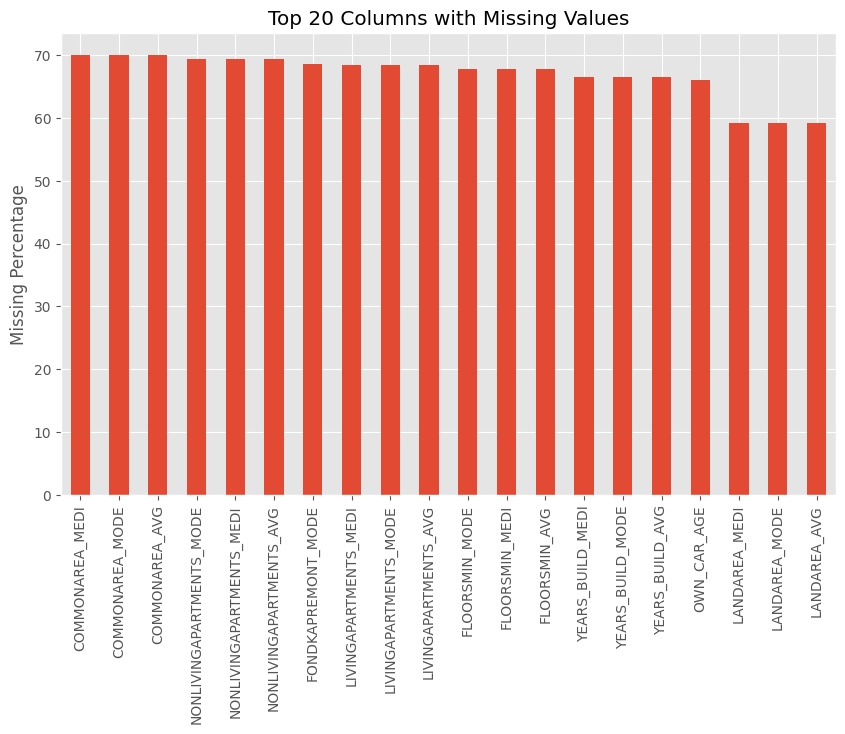

In [8]:
plt.figure(figsize=(10,6))

missing_df.sort_values(by="Missing %", ascending=False).head(20)["Missing %"].plot(kind="bar")

plt.title("Top 20 Columns with Missing Values")
plt.ylabel("Missing Percentage")
plt.show()

Observation:

• Several columns contain a high percentage of missing values.
• Columns with extremely high missing values (e.g., >50%) may be considered for removal during preprocessing.
• Missing data should be handled carefully before model building.

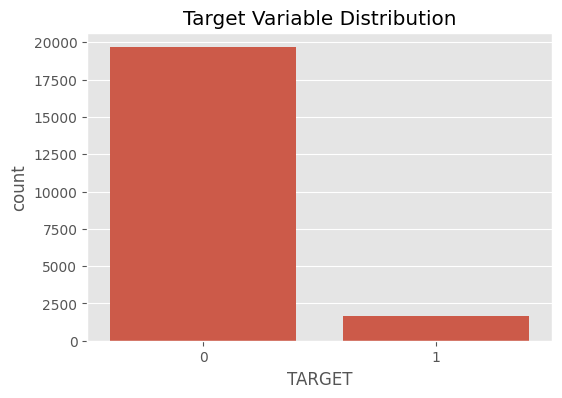

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x='TARGET', data=application)

plt.title("Target Variable Distribution")
plt.show()

In [10]:
application['TARGET'].value_counts(normalize=True) * 100

,proportion
TARGET,
0,92.132146
1,7.867854


Observation:

• TARGET = 0 represents clients who repaid the loan on time.
• TARGET = 1 represents clients with payment difficulties.
• The dataset is imbalanced, with non-defaulters significantly outnumbering defaulters.

In [12]:
application.shape
previous.shape

(42611, 37)

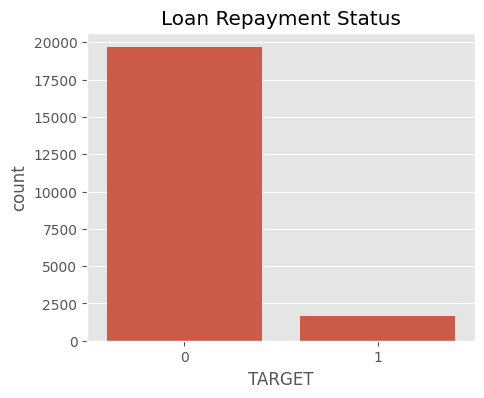

In [13]:
plt.figure(figsize=(5,4))
sns.countplot(x='TARGET', data=application)
plt.title("Loan Repayment Status")
plt.show()

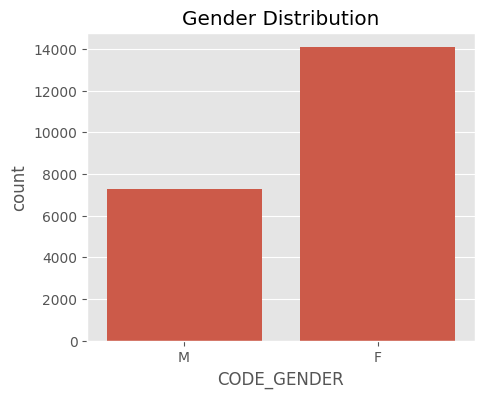

In [14]:
plt.figure(figsize=(5,4))
sns.countplot(x='CODE_GENDER', data=application)
plt.title("Gender Distribution")
plt.show()

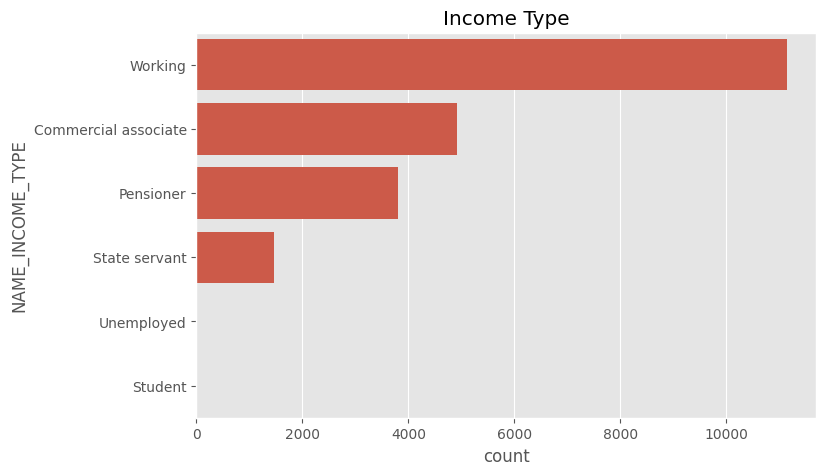

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(
    y='NAME_INCOME_TYPE',
    data=application,
    order=application['NAME_INCOME_TYPE'].value_counts().index
)
plt.title("Income Type")
plt.show()

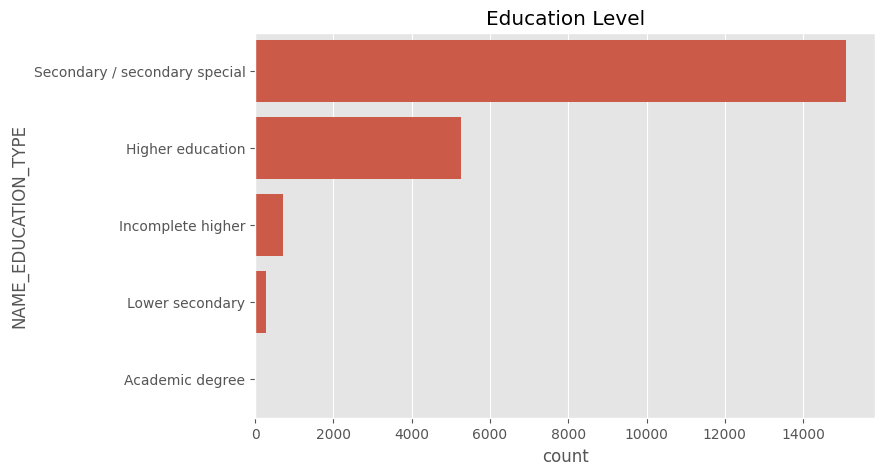

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(
    y='NAME_EDUCATION_TYPE',
    data=application,
    order=application['NAME_EDUCATION_TYPE'].value_counts().index
)
plt.title("Education Level")
plt.show()

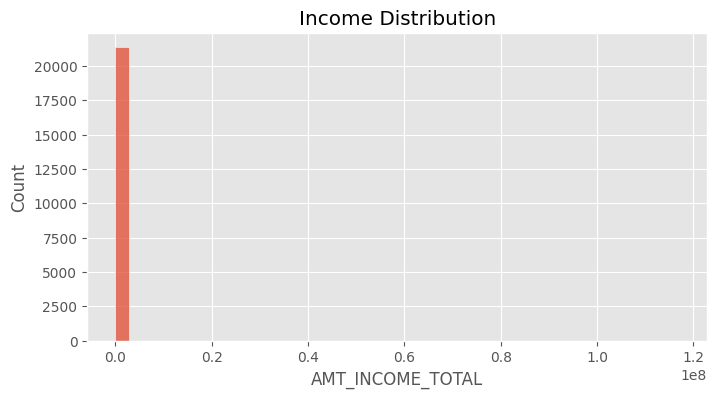

In [17]:
plt.figure(figsize=(8,4))
sns.histplot(application['AMT_INCOME_TOTAL'], bins=40)
plt.title("Income Distribution")
plt.show()

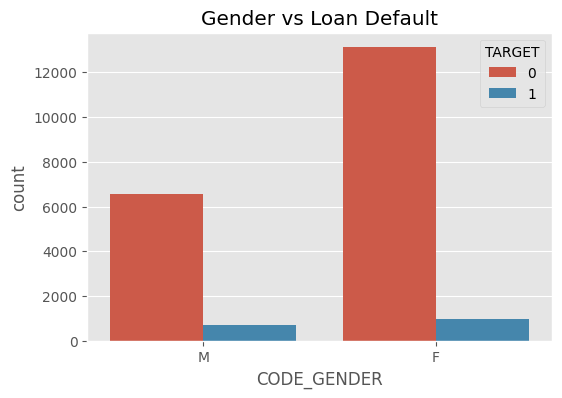

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='CODE_GENDER',
    hue='TARGET',
    data=application
)
plt.title("Gender vs Loan Default")
plt.show()

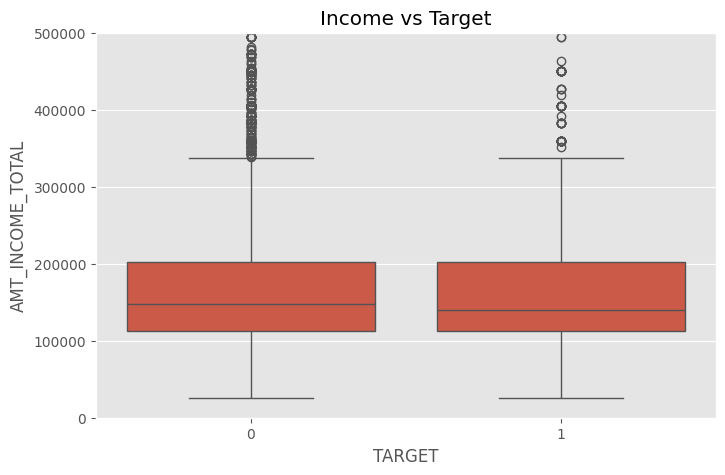

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='TARGET',
    y='AMT_INCOME_TOTAL',
    data=application
)
plt.title("Income vs Target")
plt.ylim(0,500000)
plt.show()

In [20]:
pd.crosstab(
    application['NAME_EDUCATION_TYPE'],
    application['TARGET'],
    normalize='index'
)

TARGET,0,1
NAME_EDUCATION_TYPE,,
Academic degree,1.000000,0.000000
Higher education,0.952517,0.047483
Incomplete higher,0.902954,0.097046
Lower secondary,0.898876,0.101124
Secondary / secondary special,0.911634,0.088366


In [21]:
pd.crosstab(
    application['OCCUPATION_TYPE'],
    application['TARGET'],
    normalize='index'
)

TARGET,0,1
OCCUPATION_TYPE,,
Accountants,0.940058,0.059942
Cleaning staff,0.896440,0.103560
Cooking staff,0.907035,0.092965
Core staff,0.937468,0.062532
Drivers,0.887763,0.112237
HR staff,0.902439,0.097561
High skill tech staff,0.932161,0.067839
IT staff,0.902439,0.097561
Laborers,0.907770,0.092230


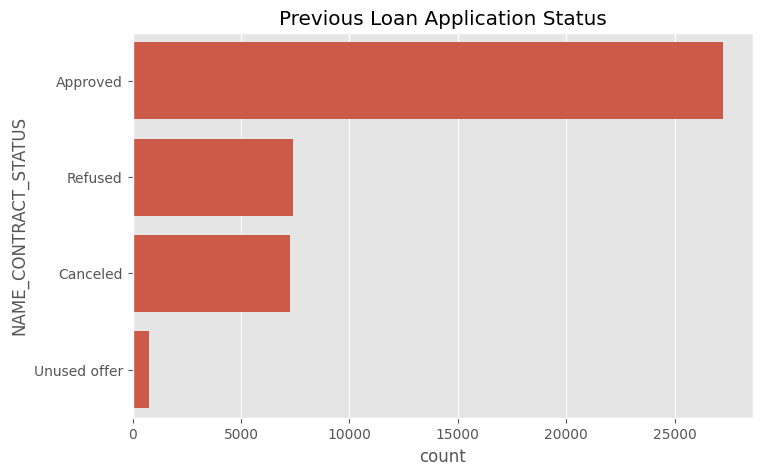

In [22]:

plt.figure(figsize=(8,5))
sns.countplot(
    y='NAME_CONTRACT_STATUS',
    data=previous,
    order=previous['NAME_CONTRACT_STATUS'].value_counts().index
)
plt.title("Previous Loan Application Status")
plt.show()

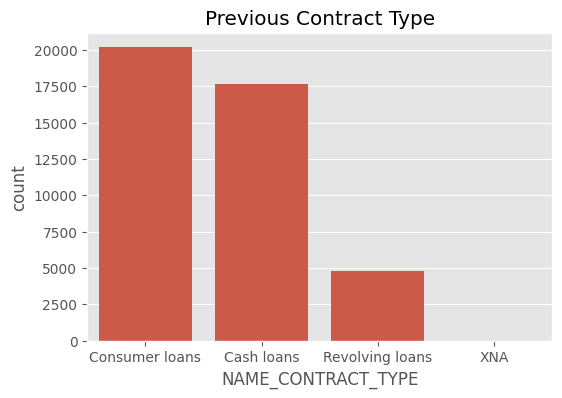

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='NAME_CONTRACT_TYPE',
    data=previous
)
plt.title("Previous Contract Type")
plt.show()

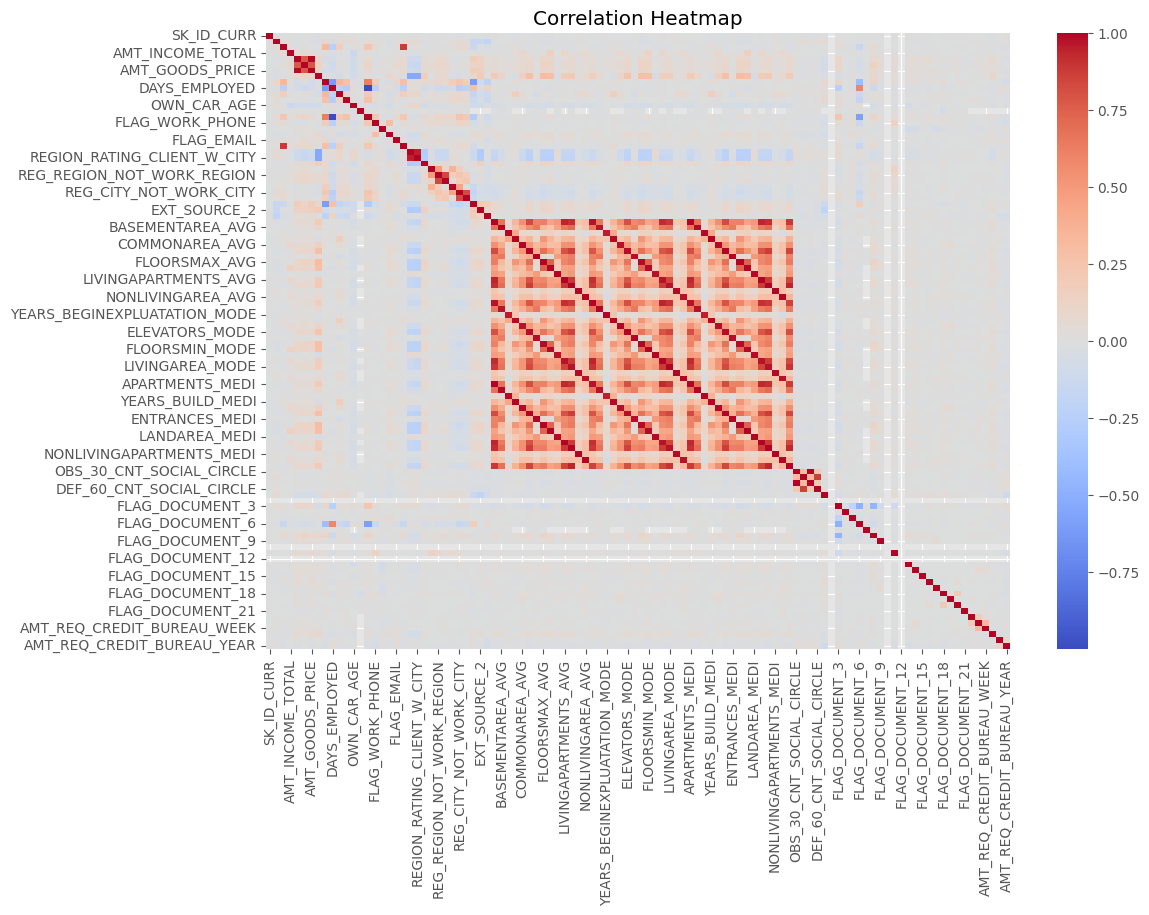

In [24]:
plt.figure(figsize=(12,8))

corr = application.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# Business Insights

- Most applicants successfully repay their loans.
- The dataset is imbalanced, with fewer defaulters than non-defaulters.
- Female applicants constitute a larger share of loan applications.
- Working professionals are the largest applicant group.
- Secondary education is the most common education level.
- Applicant income is highly skewed with several high-income outliers.
- Lower-income applicants tend to exhibit relatively higher default risk.
- Most previous loan applications were approved.
- Correlation analysis indicates that no single feature alone strongly explains default risk, suggesting multiple factors influence repayment behavior.

# Conclusion

EDA helps identify applicant characteristics associated with higher payment difficulty. These insights can support better loan approval decisions, risk-based pricing, and targeted verification while reducing the likelihood of rejecting creditworthy customers.